# Code Assignment 18 — NYC COVID-19 Daily Counts (Time-Series)

**Dataset:** [NYC DOHMH — *COVID-19 Daily Counts of Cases, Hospitalizations, and Deaths*](https://data.cityofnewyork.us/Health/COVID-19-Daily-Counts-of-Cases-Hospitalizations-an/rc75-m7u3/about_data) 
**Focus:** Build a clean **daily** time series, **visualize** with resampling (month-end, yearly), **decompose** (trend/seasonality/residual), and **test stationarity** (ADF).  
**No forecasting models** and **no ACF/PACF** yet.

---

## Instructor Guidance

 Build a clean **daily** time series from NYC COVID-19 data using **SQLite** for filtering; visualize resampled views; run **decomposition** and **ADF**.

### Pseudocode Plan 
1) **Download CSV → pandas** (parse dates) → `pd.read_csv(path, parse_dates=['date_of_interest'])`  
2) **Normalize columns to lowercase** → `df.columns = df.columns.str.lower()`  
3) **Write to SQLite** → `import sqlite3; conn = sqlite3.connect('nyc_ts.db'); df.to_sql('covid_daily', conn, if_exists='replace', index=False)`  
4) **Filter to a time window** (choose recent 12–24 months, select only needed columns)   
5) **Set DateTime index & daily frequency** → `df.set_index('date_of_interest').asfreq('D')`  
6) **Pick ONE target series** (`case_count` | `hosp_count` | `death_count`) and for now fill in missing values with zero 
7) **Resample for EDA**  
   - Month-end totals → `df[[target]].resample('M').sum()`  
   - Yearly totals → use the month-end totals to figure this code out 
8) **Decompose** (weekly seasonality) → `seasonal_decompose()`  
9) **ADF test** (raw → difference)  
   - Raw → `adfuller(s.dropna())`  
   - First difference 
10) **Short write-up**: describe trend/seasonality, ADF p-values before/after differencing, and business implications.


## Your Task

### Step 0:  Run the imports below

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


### Step 1:  Read in the data and look at it

In [18]:
df = pd.read_csv('/Users/Marcy_Student/Downloads/covid copy.csv', engine= 'python', parse_dates=['date_of_interest'])
df.shape
df.columns = df.columns.str.lower()
display(df.head())


,date_of_interest,case_count,probable_case_count,hospitalized_count,death_count,case_count_7day_avg,all_case_count_7day_avg,hosp_count_7day_avg,death_count_7day_avg,bx_case_count,...,si_case_count,si_probable_case_count,si_hospitalized_count,si_death_count,si_probable_case_count_7day_avg,si_case_count_7day_avg,si_all_case_count_7day_avg,si_hospitalized_count_7day_avg,si_death_count_7day_avg,incomplete
0,2020-02-29,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2020-03-01,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2020-03-02,0,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2020-03-03,1,0,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2020-03-04,5,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Step 2:  Keep needed columns & filter by time window 

- Chose any time window (use most recent data) that is 6 to 12 months long 


In [74]:
df['date_of_interest'].describe()

# Filter to the last 12 months based on the max date in the data
end_date = df['date_of_interest'].max()
start_date = end_date - pd.DateOffset(months=12)

df_filterd = df[df['date_of_interest'].between(start_date, end_date)]
print(df_filterd['date_of_interest'].min(), df_filterd['date_of_interest'].max(), df_filterd.shape)

# Selecting needed columns
df_needed = df_filterd[['date_of_interest','case_count','hospitalized_count','death_count']]

2024-10-13 00:00:00 2025-10-13 00:00:00 (366, 55)


/var/folders/bs/gtwb0lj97nb4v95968dmfzww0000gp/T/ipykernel_44559/555298853.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  df['date_of_interest'].describe()


### Step 3:  Create a time series object and pick your Y (case count, hospitalized count, death count, etc)

- Use the `date_of_interest` column as your index and keep it at "Daily" frequency (try looking up set_index() in pandas)
- Fill in missing values of Y with zero 

In [75]:
#Build a daily time series, pick a target metric
# Set time index & ensure daily frequency
df_needed= df_needed.set_index('date_of_interest').asfreq('D')
df_needed.head()

df_needed = df_needed.fillna(0)
Y = df_needed['case_count']

# convert datatype to numeric
df_needed['case_count'] = pd.to_numeric(df_needed['case_count'])
df_needed['hospitalized_count'] = pd.to_numeric(df_needed['hospitalized_count'])
df_needed['death_count'] = pd.to_numeric(df_needed['death_count'])


### Step 4 - Visualize the Series

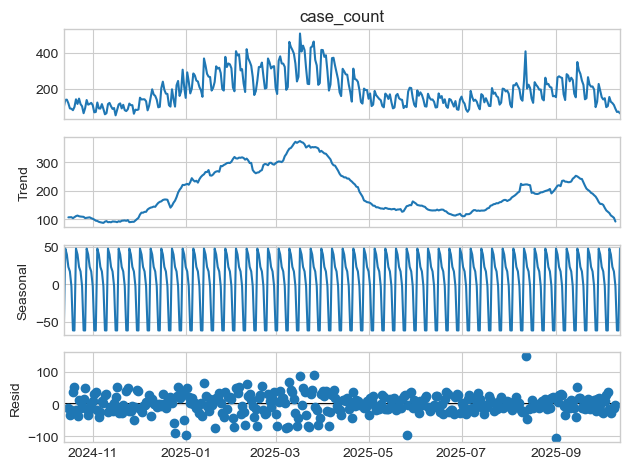

### Step 5 - Resampling EDA:  Month-end and Yearly totals 

- Use the `.resample()` function to resample the series to month end and yearly 
- Visualize both resampled series 

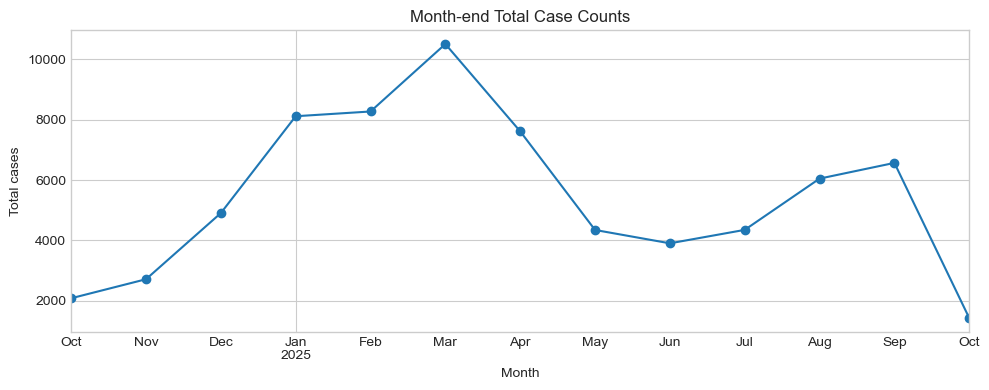

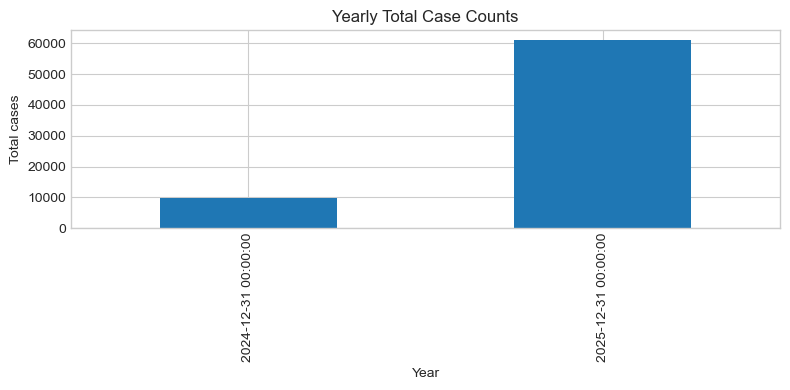

In [84]:
# CELL 5 — Resampling EDA: Month-end and Yearly totals (Pandas-only)
# Month-end 
m_end = df_needed['case_count'].resample('M').sum()

plt.figure(figsize=(10, 4))
m_end.plot(marker='o')
plt.title('Month-end Total Case Counts')
plt.xlabel('Month')
plt.ylabel('Total cases')
plt.tight_layout()
plt.show()

# Yearly totals
y_sum = df_needed['case_count'].resample('Y').sum()

plt.figure(figsize=(8, 4))
y_sum.plot(kind='bar') # only two years, a line would give a straigt line
plt.title('Yearly Total Case Counts')
plt.xlabel('Year')
plt.ylabel('Total cases')
plt.tight_layout()
plt.show()

### Step 6 - Decompose the original time series object (use period = 7 since that represents weekly seasonality)
- Make a visual of the decomposition

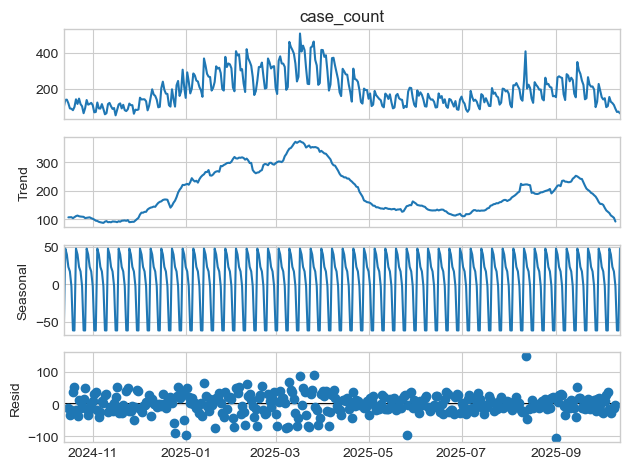

In [86]:
# CELL 6 — Decomposition (weekly seasonality → period=7)
ts = Y 

decomp = seasonal_decompose(ts, model='additive', period=7) 
fig = decomp.plot()
plt.tight_layout()
plt.show()

### Step 7 - Do the ADF test for stationarity on the original time series and for taking a difference of 1 on the time series 
- Be sure to drop missing values (if you didn't above) 

In [ ]:
# CELL 7 — ADF stationarity test: raw → difference (1) → (optional) seasonal diff(7)
print('--ADF on original---')
adf_test = adfuller(ts)
print(f'ADF Statistic: {adf_test[0]:.2f}')
print(f'p-value: {adf_test[1]:.2f}')

ts_numeric = pd.to_numeric(ts, errors='coerce')
ts_diff = ts_numeric.diff().dropna()
print('\n--- ADF Test on Differenced Data ---')
adf_test_diff = adfuller(ts_diff)
print(f'ADF Statistic: {adf_test_diff[0]:.2f}')
print(f'p-value: {adf_test_diff[1]:.2f}') 

--ADF on original---
ADF Statistic: -1.60
p-value: 0.48

--- ADF Test on Differenced Data ---
ADF Statistic: -3.78
p-value: 0.00


## We Share — Reflection 

1) **Narrative:** One sentence describing the series over your window (trend + weekly seasonality + volatility).  
2) **Stationarity:** Which transform (if any) produced p < 0.05? Why does that matter before modeling?  
3) **Operational lens:** Based on month-end and yearly views, what **calendar effects** would you brief stakeholders about?
